Assignment 2 - Machine Learning 
- Sude Yurekli


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [12]:
df = pd.read_csv("bots_vs_users.csv")

dropping collumns with more than 50% NaN or Unkonwn values, and creating a new "clean" cvs file 


In [13]:
df.replace("Unknown", pd.NA, inplace=True)

threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)

df.to_csv("cleaned_bots_vs_users.csv", index=False)


Review the new file 

In [ ]:
df = pd.read_csv("cleaned_bots_vs_users.csv")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())

print("\nTarget distribution:\n", df['target'].value_counts(normalize=True))

df.head()

Shape: (5874, 23)

Data types:
 has_domain                  float64
has_birth_date              float64
has_photo                   float64
can_post_on_wall            float64
can_send_message            float64
has_website                 float64
gender                      float64
has_short_name              float64
has_first_name              float64
has_last_name               float64
access_to_closed_profile    float64
is_profile_closed           float64
target                        int64
has_nickname                float64
has_mobile                  float64
all_posts_visible           float64
audio_available             float64
can_add_as_friend           float64
can_invite_to_group         float64
is_blacklisted              float64
is_verified                 float64
is_confirmed                float64
city                         object
dtype: object

Missing values:
 has_domain                    24
has_birth_date               856
has_photo                     24
can_post_

,has_domain,has_birth_date,has_photo,can_post_on_wall,can_send_message,has_website,gender,has_short_name,has_first_name,has_last_name,...,has_nickname,has_mobile,all_posts_visible,audio_available,can_add_as_friend,can_invite_to_group,is_blacklisted,is_verified,is_confirmed,city
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Dropping any rows that still have NaNs
- Seperating feature and target 
- Splitting data 20-80

In [ ]:
df = df.dropna()

X = df.drop(columns=['target'])
y = df['target']



Baseline	
- LogisticRegression	- Simple, interpretable, good with binary classification
Model A	
- RandomForestClassifier	- Handles mixed features well, offers feature importance

We still have city column whitch is a categorical(string) feature 
- logreg cannot handle strings so we are going to use OneHotEncoder 

In [ ]:
X_full = pd.concat([X_train, X_test])
X_full_encoded = pd.get_dummies(X_full, columns=['city'])

X_train_encoded = X_full_encoded.iloc[:len(X_train), :]
X_test_encoded = X_full_encoded.iloc[len(X_train):, :]

print("Encoded feature count:", X_train_encoded.shape[1])

Encoded feature count: 227


Now we can run the logistic regression 

In [ ]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_encoded, y_train)

y_pred = baseline_model.predict(X_test_encoded)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

Confusion Matrix:
[[291   6]
 [ 11  28]]

Classification Report:
              precision    recall  f1-score   support

           0      0.964     0.980     0.972       297
           1      0.824     0.718     0.767        39

    accuracy                          0.949       336
   macro avg      0.894     0.849     0.869       336
weighted avg      0.947     0.949     0.948       336



running RandomForest 


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_encoded, y_train)

y_rf_pred = rf_model.predict(X_test_encoded)

print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_rf_pred))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_rf_pred, digits=3))

Confusion Matrix (Random Forest):
[[297   0]
 [ 31   8]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0      0.905     1.000     0.950       297
           1      1.000     0.205     0.340        39

    accuracy                          0.908       336
   macro avg      0.953     0.603     0.645       336
weighted avg      0.916     0.908     0.880       336



Model Tuning with Grid Search

tuning logreg

In [ ]:
logreg_params = {'C': [0.01, 0.1, 1, 10, 100],'penalty': ['l2'],'solver': ['lbfgs']}

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg_grid = GridSearchCV(logreg, logreg_params, cv=5, scoring='f1', verbose=1)
logreg_grid.fit(X_train_encoded, y_train)

print("Best Logistic Regression Parameters:", logreg_grid.best_params_)
print("Best CV F1-score:", logreg_grid.best_score_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Logistic Regression Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-score: 0.725629290617849


tuning random forest 


In [ ]:
rf_params = {'n_estimators': [50, 100, 150],'max_depth': [5, 10, 15],'min_samples_split': [2, 5]}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='f1', verbose=1)
rf_grid.fit(X_train_encoded, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best CV F1-score:", rf_grid.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Random Forest Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 150}
Best CV F1-score: 0.4809638866117272


Feature Importance

Logistic Regression Feature Coefficients

Top 10 most influential features (Logistic Regression):
               Feature  Coefficient  Abs_Coefficient
97    city_Kostomuksha    -5.336370         5.336370
152  city_Petrozavodsk    -4.363521         4.363521
169         city_Satka     3.867069         3.867069
204   city_Vladivostok     3.643458         3.643458
87        city_Kataysk    -3.525104         3.525104
89          city_Kerch     3.458278         3.458278
88          city_Kazan    -3.426233         3.426233
140   city_Novosibirsk     3.387946         3.387946
196           city_Ufa     3.305034         3.305034
175    city_Simferopol    -3.195625         3.195625


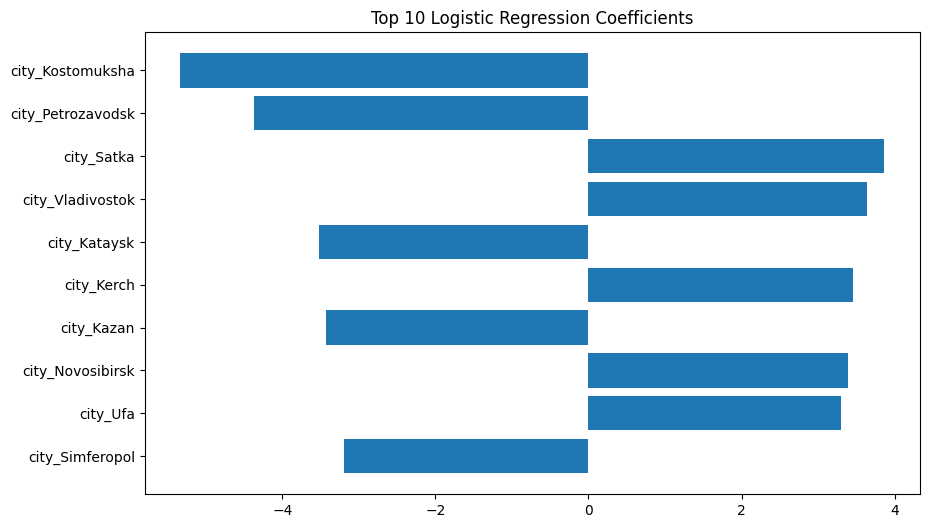

In [ ]:
best_logreg = logreg_grid.best_estimator_
coefficients = best_logreg.coef_[0]
feature_names = X_train_encoded.columns

logreg_importance = pd.DataFrame({'Feature': feature_names,'Coefficient': coefficients,'Abs_Coefficient': np.abs(coefficients)}).sort_values(by='Abs_Coefficient', ascending=False)

print("Top 10 most influential features (Logistic Regression):")
print(logreg_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(logreg_importance['Feature'][:10], logreg_importance['Coefficient'][:10])
plt.title("Top 10 Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.show()

ROC Curve & AUC — Model Comparison

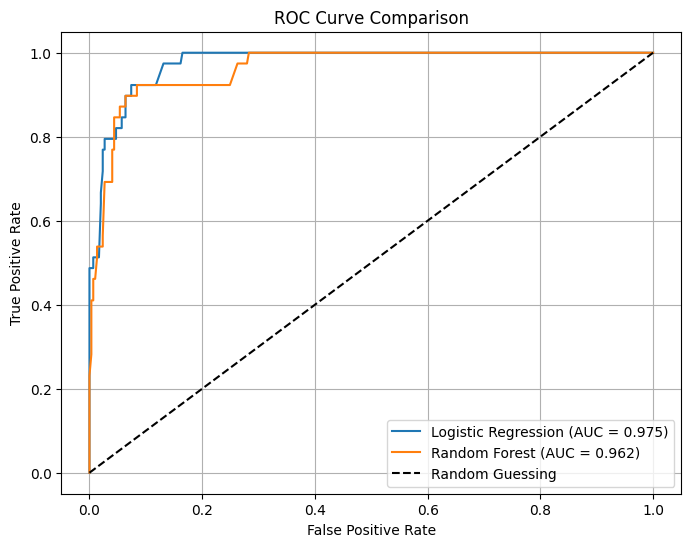

In [ ]:
y_logreg_proba = logreg_grid.best_estimator_.predict_proba(X_test_encoded)[:, 1]
y_rf_proba = rf_grid.best_estimator_.predict_proba(X_test_encoded)[:, 1]

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_logreg_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_rf_proba)

auc_logreg = roc_auc_score(y_test, y_logreg_proba)
auc_rf = roc_auc_score(y_test, y_rf_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()
